In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

In [ ]:
def deutsch_jozsa_query(num_qubits):
    qc = QuantumCircuit(num_qubits + 1)

    if np.random.randint(0, 2):
        # Flip the output qubit with a 50% chance
        qc.x(num_qubits)
    if np.random.randint(0, 2):
        # Return a constant function with a 50% chance
        return qc

    # Sample half of the possible input states to create a balanced function
    on_states = np.random.choice(
        range(2 ** num_qubits),  # possible input states
        2 ** num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once
    )

    # Helper function to add X gates to the circuit based on a bit string
    def add_x(qc, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc.x(qubit)
        return qc

    # Add the multi-controlled X gates to the circuit for each sampled input state
    for state in on_states:
        qc.barrier() 
        qc = add_x(qc, f"{state:0b}") # Add X gates to the circuit based on the binary representation of the state
        qc.mcx(list(range(num_qubits)), num_qubits) # Apply a multi-controlled X gate to the output qubit
        qc = add_x(qc, f"{state:0b}") # Remove the X gates to reset the input qubits to their original state

    qc.barrier()

    return qc

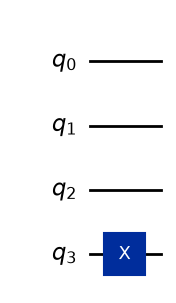

In [13]:
display(deutsch_jozsa_query(3).draw(output="mpl"))

In [ ]:
def compile_circuit(function: QuantumCircuit):
    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    
    # Initialize the output qubit to |1>
    qc.x(n)
    
    # Apply Hadamard gates to all qubits
    qc.h(range(n + 1))
    
    # Compose the oracle function into the circuit
    qc.compose(function, inplace=True)
    
    # Apply Hadamard gates to the input qubits again
    qc.h(range(n))
    
    # Measure the input qubits
    qc.measure(range(n), range(n))
    return qc

In [15]:
def deutsch_jozsa_algorithm(function: QuantumCircuit):
    qc = compile_circuit(function)

    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if "1" in measurements[0]:
        return "balanced"
    return "constant"

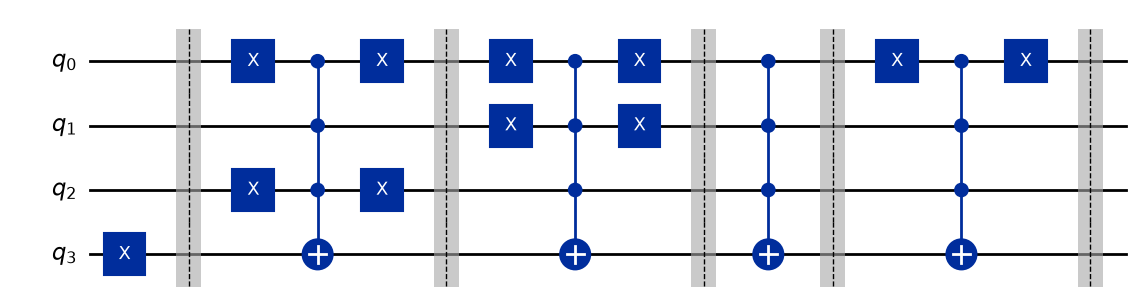

'balanced'

In [19]:
f = deutsch_jozsa_query(3)
display(f.draw("mpl"))
display(deutsch_jozsa_algorithm(f))